<a href="https://colab.research.google.com/github/mitawati23/Code-MachineLearning-Pro-Step/blob/main/KICH_KIDNEY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Path file
file_path1 = "/content/drive/MyDrive/TCGA-KICH/TCIA_TCGA-KICH_09-16-2015-nbia-digest.xlsx"
file_path2 = "/content/drive/MyDrive/TCGA-KICH/TCGA-KICH.clinical.tsv"

# Baca file
df1 = pd.read_excel(file_path1)
df2 = pd.read_csv(file_path2, sep="\t")

# List patient_id yang mau difilter
patient_ids = [
    'TCGA-KM-8438','TCGA-KM-8439','TCGA-KM-8440','TCGA-KM-8441','TCGA-KM-8442',
    'TCGA-KM-8443','TCGA-KM-8476','TCGA-KM-8477','TCGA-KM-8639','TCGA-KN-8419',
    'TCGA-KN-8422','TCGA-KN-8424','TCGA-KN-8425','TCGA-KN-8427','TCGA-KN-8430',
    # 'TCGA-BP-4349',
    # 'TCGA-BP-4351','TCGA-BP-4762','TCGA-BP-4799','TCGA-BP-4807','TCGA-BP-4989',
    # 'TCGA-BP-4999','TCGA-BP-5006','TCGA-BP-5010','TCGA-BP-5200','TCGA-CW-5583',
    # 'TCGA-CW-5584','TCGA-CW-5585','TCGA-CW-5587','TCGA-CW-5588','TCGA-CW-6087',
    # 'TCGA-CW-6090','TCGA-CZ-4857',
]

# Filter clinical data sesuai patient list
df2_filtered = df2[df2["submitter_id"].isin(patient_ids)][
    ["submitter_id", "ajcc_pathologic_stage.diagnoses"]
]

# Group per pasien, ambil stage unik
df2_stage = (
    df2_filtered.groupby("submitter_id")["ajcc_pathologic_stage.diagnoses"]
    .unique()
    .reset_index()
    .rename(columns={"submitter_id": "Patient ID", "ajcc_pathologic_stage.diagnoses": "Stages"})
)

# Tampilkan hasil full (Patient ID dan Stage unik)
print("=== Daftar Pasien dan Stage ===")
print(df2_stage.to_string(index=False))

# Hitung jumlah masing-masing stage (meledakkan array stage dulu)
stage_counts = df2_stage["Stages"].explode().value_counts()

print("\n=== Jumlah Pasien per Stage ===")
print(stage_counts)

=== Daftar Pasien dan Stage ===
  Patient ID      Stages
TCGA-KM-8438  [Stage II]
TCGA-KM-8439   [Stage I]
TCGA-KM-8440 [Stage III]
TCGA-KM-8441   [Stage I]
TCGA-KM-8442  [Stage II]
TCGA-KM-8443  [Stage II]
TCGA-KM-8476   [Stage I]
TCGA-KM-8477   [Stage I]
TCGA-KM-8639   [Stage I]
TCGA-KN-8419  [Stage II]
TCGA-KN-8422   [Stage I]
TCGA-KN-8424   [Stage I]
TCGA-KN-8425   [Stage I]
TCGA-KN-8427  [Stage IV]
TCGA-KN-8430   [Stage I]

=== Jumlah Pasien per Stage ===
Stages
Stage I      9
Stage II     4
Stage III    1
Stage IV     1
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Path file
file_path1 = "/content/drive/MyDrive/TCGA-KICH/TCIA_TCGA-KICH_09-16-2015-nbia-digest.xlsx"
file_path2 = "/content/drive/MyDrive/TCGA-KICH/TCGA-KICH.clinical.tsv"

# Baca file
df1 = pd.read_excel(file_path1)
df2 = pd.read_csv(file_path2, sep="\t")

# Ambil kolom patient ID dari Excel
df1_ids = df1[["Patient ID"]].dropna().drop_duplicates()

# Merge dengan data clinical pakai patient ID
df_matched = pd.merge(
    df1_ids,
    df2[["submitter_id", "ajcc_pathologic_stage.diagnoses"]],
    left_on="Patient ID",
    right_on="submitter_id",
    how="inner"   # hanya ambil yang match
)

# Rename kolom biar rapi
df_matched = df_matched.rename(columns={
    "ajcc_pathologic_stage.diagnoses": "Stage"
}).drop(columns=["submitter_id"])

print("=== Data Matching TCIA x Clinical ===")
print(df_matched.head(20))

# Hitung distribusi stage
stage_counts = df_matched["Stage"].value_counts()
print("\n=== Jumlah Pasien per Stage ===")
print(stage_counts)

=== Data Matching TCIA x Clinical ===
      Patient ID      Stage
0   TCGA-KN-8427   Stage IV
1   TCGA-KN-8427   Stage IV
2   TCGA-KN-8424    Stage I
3   TCGA-KN-8424    Stage I
4   TCGA-KN-8425    Stage I
5   TCGA-KN-8425    Stage I
6   TCGA-KN-8430    Stage I
7   TCGA-KN-8430    Stage I
8   TCGA-KN-8422    Stage I
9   TCGA-KN-8422    Stage I
10  TCGA-KN-8419   Stage II
11  TCGA-KN-8419   Stage II
12  TCGA-KM-8439    Stage I
13  TCGA-KM-8438   Stage II
14  TCGA-KM-8440  Stage III
15  TCGA-KM-8442   Stage II
16  TCGA-KM-8441    Stage I
17  TCGA-KM-8477    Stage I
18  TCGA-KM-8476    Stage I
19  TCGA-KM-8639    Stage I

=== Jumlah Pasien per Stage ===
Stage
Stage I      13
Stage II      5
Stage IV      2
Stage III     1
Name: count, dtype: int64


In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.3 MB/s eta 0:00:00


In [ ]:
import os
import pydicom
from collections import Counter

# === 1. Mount Google Drive jika belum ===
from google.colab import drive
drive.mount('/content/drive')

# === 2. Path ke folder dataset ===
patient_dir = '/content/drive/MyDrive/TCGA-KICH'

# === 3. Inisialisasi ===
modalities = []
dcm_files = []
sample_dict = {}  # untuk simpan 1 contoh file tiap modality

# === 4. Loop semua file DICOM ===
for root, dirs, files in os.walk(patient_dir):
    for file in files:
        filepath = os.path.join(root, file)
        try:
            ds = pydicom.dcmread(filepath, stop_before_pixels=True)
            modality = getattr(ds, 'Modality', None)
            if modality:
                dcm_files.append(filepath)
                modalities.append(modality)
                # simpan satu contoh file per modality
                if modality not in sample_dict:
                    sample_dict[modality] = filepath
        except Exception:
            continue

# === 5. Ringkasan hasil ===
print("Total file DICOM valid ditemukan:", len(dcm_files))
print("Distribusi modality:", Counter(modalities))

# === 6. Tampilkan contoh metadata dari tiap modality ===
for modality, sample_path in sample_dict.items():
    ds = pydicom.dcmread(sample_path, stop_before_pixels=True)
    print(f"\nContoh {modality}:")
    print("  File path:", sample_path)
    print("  Patient ID:", getattr(ds, "PatientID", "N/A"))
    print("  Study Date:", getattr(ds, "StudyDate", "N/A"))
    print("  SOP Instance UID:", getattr(ds, "SOPInstanceUID", "N/A"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total file DICOM valid ditemukan: 3724
Distribusi modality: Counter({'CT': 1946, 'MR': 1778})

Contoh CT:
  File path: /content/drive/MyDrive/TCGA-KICH/TCGA-KN-8430/08-24-1998-NA-CT ABDOMEN WWO-61030/5.000000-8MIN AP  3.0  SPO  cor-53026/1-001.dcm
  Patient ID: TCGA-KN-8430
  Study Date: 19980824
  SOP Instance UID: 1.3.6.1.4.1.14519.5.2.1.3671.4011.300267014184302715531767753897

Contoh MR:
  File path: /content/drive/MyDrive/TCGA-KICH/TCGA-KN-8427/01-20-1998-NA-MS4183GAD   Abdomen w  wo-27429/9.000000-Asset cal-49405/1-02.dcm
  Patient ID: TCGA-KN-8427
  Study Date: 19980120
  SOP Instance UID: 1.3.6.1.4.1.14519.5.2.1.3671.4011.124717585530823709710574794271


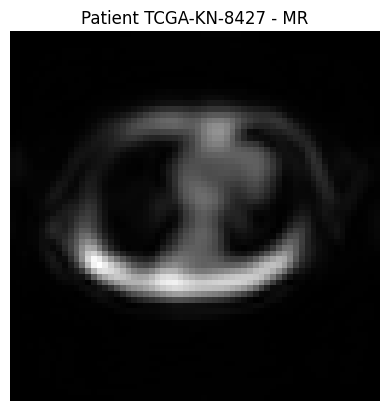

In [ ]:
import matplotlib.pyplot as plt
import pydicom

# Ambil satu file DICOM contoh (misalnya MR)
dcm_sample = [f for f in dcm_files if pydicom.dcmread(f, stop_before_pixels=True).Modality == "MR"][0]

# Baca dengan pixel array
example_dcm = pydicom.dcmread(dcm_sample)

img = example_dcm.pixel_array

plt.imshow(img, cmap="gray")
plt.title(f"Patient {example_dcm.PatientID} - {example_dcm.Modality}")
plt.axis("off")
plt.show()

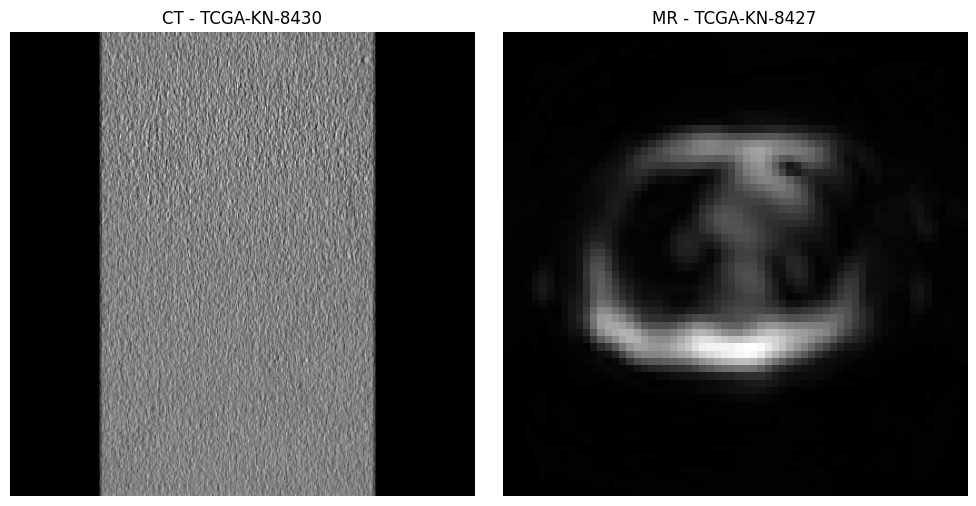

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

for ax, modality in zip(axes, ["CT", "MR"]):
    dcm_sample = [f for f in dcm_files if pydicom.dcmread(f, stop_before_pixels=True).Modality == modality][1]
    ds = pydicom.dcmread(dcm_sample)
    img = ds.pixel_array

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{modality} - {ds.PatientID}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Ambil kolom patient ID dari Excel
df1_ids = df1[["Patient ID"]].dropna().drop_duplicates()

# Merge dengan data clinical pakai patient ID
df_matched = pd.merge(
    df1_ids,
    df2[["submitter_id", "ajcc_pathologic_stage.diagnoses"]],
    left_on="Patient ID",
    right_on="submitter_id",
    how="inner"
)

# Rename kolom biar rapi
df_matched = df_matched.rename(columns={
    "ajcc_pathologic_stage.diagnoses": "Stage"
}).drop(columns=["submitter_id"])

In [ ]:
import pandas as pd

# --- 1. Normalisasi nama kolom agar konsisten ---
df1.columns = df1.columns.str.strip().str.lower().str.replace(" ", "_")
df_matched.columns = df_matched.columns.str.strip().str.lower().str.replace(" ", "_")

# --- 2. Pastikan format Patient ID sama ---
df1["patient_id"] = df1["patient_id"].astype(str).str.upper().str.strip()
df_matched["patient_id"] = df_matched["patient_id"].astype(str).str.upper().str.strip()

# --- 3. Gabungkan metadata dengan clinical stage ---
df_meta_stage = pd.merge(
    df1,
    df_matched[["patient_id", "stage"]],
    on="patient_id",
    how="inner"
)

# --- 4. Cek kolom yang tersedia ---
kolom_tampil = [
    "patient_id",
    "stage",
    "study_instance_uid",
    "series_instance_uid",
    "modality",
    "series_description"
]
kolom_tersedia = [k for k in kolom_tampil if k in df_meta_stage.columns]

# --- 5. Tampilkan hasil ---
print("\n=== Data Gabungan Metadata × Stage Klinis ===")
print(df_meta_stage[kolom_tersedia].head(5))
print(f"\nTotal data hasil merge: {len(df_meta_stage)} baris")


=== Data Gabungan Metadata × Stage Klinis ===
     patient_id     stage                                 study_instance_uid  \
0  TCGA-KN-8427  Stage IV  1.3.6.1.4.1.14519.5.2.1.3671.4011.320346731786...   
1  TCGA-KN-8427  Stage IV  1.3.6.1.4.1.14519.5.2.1.3671.4011.320346731786...   
2  TCGA-KN-8427  Stage IV  1.3.6.1.4.1.14519.5.2.1.3671.4011.320346731786...   
3  TCGA-KN-8427  Stage IV  1.3.6.1.4.1.14519.5.2.1.3671.4011.320346731786...   
4  TCGA-KN-8427  Stage IV  1.3.6.1.4.1.14519.5.2.1.3671.4011.320346731786...   

                                 series_instance_uid modality  \
0  1.3.6.1.4.1.14519.5.2.1.3671.4011.124318797383...       MR   
1  1.3.6.1.4.1.14519.5.2.1.3671.4011.124318797383...       MR   
2  1.3.6.1.4.1.14519.5.2.1.3671.4011.175906114881...       MR   
3  1.3.6.1.4.1.14519.5.2.1.3671.4011.175906114881...       MR   
4  1.3.6.1.4.1.14519.5.2.1.3671.4011.586746414399...       MR   

  series_description  
0                loc  
1                loc  
2          A

In [ ]:
print("Kolom yang tersedia di df_meta_stage:")
print(df_meta_stage.columns.tolist())

Kolom yang tersedia di df_meta_stage:
['patient_id', 'patient_name', 'patient_birth_date', 'patient_sex', 'ethnic_group', 'phantom', 'species_code', 'species_description', 'study_instance_uid', 'study_date', 'study_description', 'admitting_diagnosis_description', 'study_id', 'patient_age', 'longitudinal_temporal_event_type', 'longitudinal_temporal_offset_from_event', 'series_instance_uid', 'project', 'modality', 'protocol_name', 'series_date', 'series_description', 'body_part_examined', 'series_number', 'annotations_flag', 'manufacturer', 'manufacturer_model_name', 'software_versions', 'image_count', 'max_submission_timestamp', 'license_name', 'license_uri', 'collection_uri', 'file_size', 'date_released', 'third_party_analysis', 'stage']


In [ ]:
example = df_meta_stage[df_meta_stage["stage"].str.contains("Stage II", case=False, na=False)].iloc[0]

In [ ]:
print("Kolom df_matched:", df_matched.columns.tolist())
print("Kolom df1:", df1.columns.tolist())

Kolom df_matched: ['patient_id', 'stage']
Kolom df1: ['patient_id', 'patient_name', 'patient_birth_date', 'patient_sex', 'ethnic_group', 'phantom', 'species_code', 'species_description', 'study_instance_uid', 'study_date', 'study_description', 'admitting_diagnosis_description', 'study_id', 'patient_age', 'longitudinal_temporal_event_type', 'longitudinal_temporal_offset_from_event', 'series_instance_uid', 'project', 'modality', 'protocol_name', 'series_date', 'series_description', 'body_part_examined', 'series_number', 'annotations_flag', 'manufacturer', 'manufacturer_model_name', 'software_versions', 'image_count', 'max_submission_timestamp', 'license_name', 'license_uri', 'collection_uri', 'file_size', 'date_released', 'third_party_analysis']


In [ ]:
# Lihat semua nilai unik di kolom stage
print(df_meta_stage["stage"].unique())

['Stage IV' 'Stage I' 'Stage II' 'Stage III']


Total DICOM ditemukan: 3724


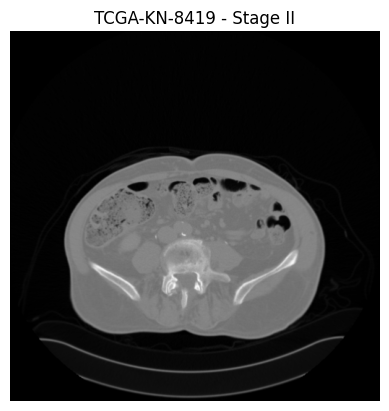

In [ ]:
import os
import pydicom
import matplotlib.pyplot as plt

# --- Pilih pasien Stage II ---
example = df_meta_stage[df_meta_stage["stage"] == "Stage II"].iloc[0]

patient_id = example["patient_id"]
series_uid = example["series_instance_uid"]

# --- Tentukan folder DICOM di Drive ---
patient_dir = '/content/drive/MyDrive/TCGA-KICH'
dicom_files = []

# Cari semua file DICOM
for root, _, files in os.walk(patient_dir):
    for f in files:
        if f.lower().endswith(".dcm"):
            dicom_files.append(os.path.join(root, f))

print(f"Total DICOM ditemukan: {len(dicom_files)}")

# --- Tampilkan salah satu DICOM ---
if dicom_files:
    dcm = pydicom.dcmread(dicom_files[0])
    plt.imshow(dcm.pixel_array, cmap="gray")
    plt.title(f"{patient_id} - {example['stage']}")
    plt.axis("off")
    plt.show()
else:
    print("⚠️ Tidak ada file DICOM ditemukan di folder pasien ini.")

Total DICOM ditemukan: 3724


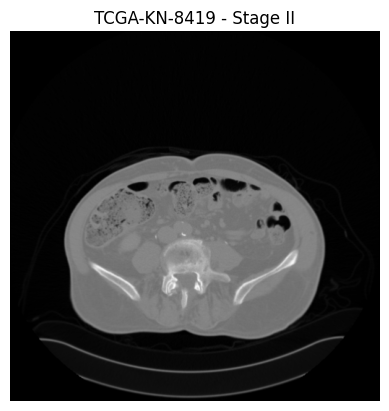

In [ ]:
import os
import pydicom
import matplotlib.pyplot as plt

# Pilih 1 pasien dengan Stage tertentu, misalnya Stage II
example = df_meta_stage[df_meta_stage["stage"].str.contains("Stage II", na=False)].iloc[0]

patient_id = example["patient_id"]
series_uid = example["series_instance_uid"]

# Cari file DICOM dalam folder sesuai patient
# patient_dir = os.path.join(r"D:\MBKM-Research\manifest-1759743526628\TCGA-KICH", patient_id)
patient_dir = '/content/drive/MyDrive/TCGA-KICH'
dicom_files = []
for root, _, files in os.walk(patient_dir):
    for f in files:
        if f.endswith(".dcm"):
            dicom_files.append(os.path.join(root, f))

print(f"Total DICOM ditemukan: {len(dicom_files)}")

# Baca dan tampilkan salah satu DICOM
dcm = pydicom.dcmread(dicom_files[0])
plt.imshow(dcm.pixel_array, cmap="gray")
plt.title(f"{patient_id} - {example['stage']}")
plt.axis("off")
plt.show()

In [ ]:
# ==========================
# STEP 1: Import libraries
# ==========================
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Buat folder output untuk hasil analisis
os.makedirs("analysisResults", exist_ok=True)

In [ ]:
import os

path = "/content/drive/MyDrive/TCGA-KICH"
print(os.listdir(path))

['TCGA-KICH.clinical.tsv', 'TCIA_TCGA-KICH_09-16-2015-nbia-digest.xlsx', 'LICENSE', 'TCGA-KN-8430', 'TCGA-KN-8424', 'TCGA-KN-8427', 'TCGA-KN-8425', 'TCGA-KN-8422', 'TCGA-KM-8443', 'TCGA-KM-8477', 'TCGA-KM-8476', 'TCGA-KN-8419', 'TCGA-KM-8639', 'TCGA-KM-8442', 'TCGA-KM-8441', 'TCGA-KM-8440', 'TCGA-KM-8439', 'TCGA-KM-8438', 'metadata.csv', 'selected_features_anova.csv', 'selected_features_all.csv']


In [ ]:
# ==========================
# STEP 2: Load Dataset
# ==========================

import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Path file metadata klinis (format CSV)
clinical_file = "/content/drive/MyDrive/TCGA-KICH/TCGA-KICH.clinical.tsv"

# Baca dataset
data = pd.read_csv(clinical_file, sep="\t")
print("✅ Dataset klinis berhasil dibaca!")
print("Ukuran dataset:", data.shape)
print("Kolom pertama:", data.columns[:10].tolist())

# ==========================
# Tentukan kolom label (stadium / stage)
# ==========================

# Deteksi otomatis kolom yang mengandung kata 'stage'
possible_labels = [c for c in data.columns if "stage" in c.lower()]
print("Kolom kandidat label:", possible_labels)

# Pilih salah satu (ubah jika perlu)
if len(possible_labels) > 0:
    label_col = possible_labels[0]
    print(f"Menggunakan kolom label: {label_col}")
else:
    raise ValueError("Tidak ditemukan kolom yang mengandung kata 'stage' di metadata.csv")

# Hapus baris dengan label kosong
data = data.dropna(subset=[label_col])

# Encode label (jika teks) - Fit on all unique labels before splitting
if data[label_col].dtype == 'object':
    le = LabelEncoder()
    le.fit(data[label_col].unique()) # Fit on all unique labels in the entire dataset
    data[label_col] = le.transform(data[label_col]) # Transform the label column in the original data

print("Kelas label setelah encoding:", le.classes_)


# ==========================
# Pisahkan fitur dan label
# ==========================
# NOTE: You need to define which columns are your features (X).
# For now, we will drop the label column to create X,
# but you should replace this with your feature selection logic.
X = data.drop(columns=[label_col])
y = data[label_col]


print("\n✅ Data siap digunakan!")
print("Jumlah fitur:", X.shape[1], "| Jumlah sampel:", X.shape[0])

✅ Dataset klinis berhasil dibaca!
Ukuran dataset: (105, 89)
Kolom pertama: ['sample', 'id', 'disease_type', 'case_id', 'submitter_id', 'primary_site', 'cigarettes_per_day.exposures', 'alcohol_history.exposures', 'years_smoked.exposures', 'race.demographic']
Kolom kandidat label: ['ajcc_pathologic_stage.diagnoses']
Menggunakan kolom label: ajcc_pathologic_stage.diagnoses
Kelas label setelah encoding: ['Stage I' 'Stage II' 'Stage III' 'Stage IV']

✅ Data siap digunakan!
Jumlah fitur: 88 | Jumlah sampel: 105


In [ ]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# Select only numeric columns from X
X_numeric = X.select_dtypes(include=np.number)

# Impute missing values (e.g., with the mean)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_numeric)

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Hapus fitur yang tidak bervariasi
vt = VarianceThreshold(threshold=0.01)
X_var = vt.fit_transform(X_scaled)

print("Fitur awal:", X.shape[1])
print("Fitur numerik setelah seleksi:", X_numeric.shape[1])
print("Fitur setelah imputation, scaling, dan variance filter:", X_var.shape[1])

Fitur awal: 88
Fitur numerik setelah seleksi: 20
Fitur setelah imputation, scaling, dan variance filter: 19


DATA PREPROCESSING

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1️⃣ Load dataset
# Specify the tab separator for the TSV file and skip bad lines
data = pd.read_csv("/content/drive/MyDrive/TCGA-KICH/TCGA-KICH.clinical.tsv", sep="\t", on_bad_lines='skip')
print("Shape:", data.shape)
display(data.head())

# Print column names to check if they are parsed correctly
print("\nColumn names after loading:\n", data.columns.tolist())

# 2️⃣ Cek missing values
print("\nMissing Values:\n", data.isnull().sum())

# 3️⃣ Hapus kolom dengan missing value terlalu banyak (>50%)
threshold = len(data) * 0.5
data = data.dropna(thresh=threshold, axis=1)

# 4️⃣ Imputasi nilai kosong dengan median untuk numeric dan modus untuk kategori
for col in data.columns:
    if data[col].dtype == 'object':
        # Use .iloc[0] to handle cases where mode might return multiple values
        data[col].fillna(data[col].mode().iloc[0], inplace=True)
    else:
        data[col].fillna(data[col].median(), inplace=True)

# 5️⃣ Encode label target
# Use the correct label column identified previously
label_col = 'ajcc_pathologic_stage.diagnoses'
le = LabelEncoder()
# Ensure the label column exists after dropping columns with too many missing values
if label_col in data.columns:
  data[label_col] = le.fit_transform(data[label_col])
else:
  raise ValueError(f"Label column '{label_col}' not found after dropping columns with missing values.")


# 6️⃣ Pisahkan fitur dan label
X = data.drop(columns=[label_col])
y = data[label_col]

# 7️⃣ Normalisasi (Standard Scaler)
scaler = StandardScaler()
# Ensure that only numeric columns are scaled
X_numeric = X.select_dtypes(include=np.number)
X_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X_numeric.columns)

# You might want to keep non-numeric columns separately or decide how to handle them
# For now, X_scaled only contains the scaled numeric features.

Shape: (105, 89)


,sample,id,disease_type,case_id,submitter_id,primary_site,cigarettes_per_day.exposures,alcohol_history.exposures,years_smoked.exposures,race.demographic,...,specimen_type.samples,is_ffpe.samples,tissue_type.samples,preservation_method.samples,days_to_collection.samples,initial_weight.samples,intermediate_dimension.samples,pathology_report_uuid.samples,shortest_dimension.samples,longest_dimension.samples
0,TCGA-UW-A72Q-01A,e2ee1ddf-985e-491e-8e0c-39f9731fee7a,Adenomas and Adenocarcinomas,e2ee1ddf-985e-491e-8e0c-39f9731fee7a,TCGA-UW-A72Q,Kidney,NaN,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,366.0,250.0,NaN,6523685F-8E71-4BC6-8402-F3FBD3332F32,NaN,NaN
1,TCGA-NP-A5H6-01A,8ee83284-3cdd-44d9-a3e2-2a567f10b605,Adenomas and Adenocarcinomas,8ee83284-3cdd-44d9-a3e2-2a567f10b605,TCGA-NP-A5H6,Kidney,NaN,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,325.0,90.0,NaN,F5F15B2B-759D-4195-8C33-33C1D6DF8F25,NaN,NaN
2,TCGA-NP-A5H1-01A,c8890a69-cd2f-41d1-9280-769932228690,Adenomas and Adenocarcinomas,c8890a69-cd2f-41d1-9280-769932228690,TCGA-NP-A5H1,Kidney,NaN,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,517.0,70.0,NaN,6B36ACD0-3F89-4240-8A34-9765FA673403,NaN,NaN
3,TCGA-NP-A5H5-01A,b947dcf8-c83a-4bb0-b517-6b5989421c61,Adenomas and Adenocarcinomas,b947dcf8-c83a-4bb0-b517-6b5989421c61,TCGA-NP-A5H5,Kidney,NaN,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,337.0,60.0,NaN,CFC9112B-5398-4692-AD18-4055BC8EF49D,NaN,NaN
4,TCGA-UW-A72K-01A,b9356af2-c448-4809-ae29-e8b80f65fa73,Adenomas and Adenocarcinomas,b9356af2-c448-4809-ae29-e8b80f65fa73,TCGA-UW-A72K,Kidney,1.643836,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,709.0,560.0,NaN,1BBCA936-0E8A-4485-A26E-EA998B326F54,NaN,NaN



Column names after loading:
 ['sample', 'id', 'disease_type', 'case_id', 'submitter_id', 'primary_site', 'cigarettes_per_day.exposures', 'alcohol_history.exposures', 'years_smoked.exposures', 'race.demographic', 'gender.demographic', 'ethnicity.demographic', 'vital_status.demographic', 'age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'year_of_death.demographic', 'primary_site.project', 'project_id.project', 'disease_type.project', 'name.project', 'name.program.project', 'tissue_source_site_id.tissue_source_site', 'code.tissue_source_site', 'name.tissue_source_site', 'project.tissue_source_site', 'bcr_id.tissue_source_site', 'pack_years_smoked.exposures', 'days_to_death.demographic', 'entity_submitter_id.annotations', 'notes.annotations', 'submitter_id.annotations', 'classification.annotations', 'entity_id.annotations', 'created_datetime.annotations', 'annotation_id.annotations', 'entity_type.annotations', 'updated_datetime.annotations', 'case_id.an

/tmp/ipython-input-1444738263.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode().iloc[0], inplace=True)
/tmp/ipython-input-1444738263.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

FE

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Ensure X and y are defined (assuming previous cells have been run)

# Impute missing values (e.g., with the mean)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X.select_dtypes(include=np.number))
X_imputed = pd.DataFrame(X_imputed, columns=X.select_dtypes(include=np.number).columns)


# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled, columns=X_imputed.columns)


# 1️⃣ Seleksi lanjutan dengan LASSO
# Use a smaller alpha or increase max_iter if no features are selected
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled, y)

model = SelectFromModel(lasso, prefit=True)
X_selected_lasso = model.transform(X_scaled)

# Get the names of the selected features
selected_features_names_lasso = X_scaled.columns[model.get_support()]

print(f"Jumlah fitur akhir setelah LASSO: {X_selected_lasso.shape[1]}")
print("Selected feature names (LASSO):", selected_features_names_lasso.tolist())

# Fallback: If Lasso selects 0 features, use all scaled numeric features
if X_selected_lasso.shape[1] == 0:
    print("Lasso selected 0 features. Using all scaled numeric features.")
    X_selected = X_scaled
    selected_features_names = X_scaled.columns.tolist()
else:
    X_selected = X_selected_lasso
    selected_features_names = selected_features_names_lasso.tolist()

print(f"Jumlah fitur yang akan digunakan untuk training: {X_selected.shape[1]}")

Jumlah fitur akhir setelah LASSO: 0
Selected feature names (LASSO): []
Lasso selected 0 features. Using all scaled numeric features.
Jumlah fitur yang akan digunakan untuk training: 13


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_base.py:122: UserWarning: No features were selected: either the data is too noisy or the selection test too strict.
  warnings.warn(


MODEL DEVELOPMENT & EVALUATION

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Split data using the selected features
# Make sure X_selected and y are defined from previous steps
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6190476190476191

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.88      0.74         8
           1       0.67      0.57      0.62         7
           2       1.00      0.25      0.40         4
           3       0.33      0.50      0.40         2

    accuracy                           0.62        21
   macro avg       0.66      0.55      0.54        21
weighted avg       0.69      0.62      0.60        21


Confusion Matrix:
 [[7 1 0 0]
 [3 4 0 0]
 [1 0 1 2]
 [0 1 0 1]]


MODEL VALIDATION USING AI

CV mean accuracy: 0.36190476190476184


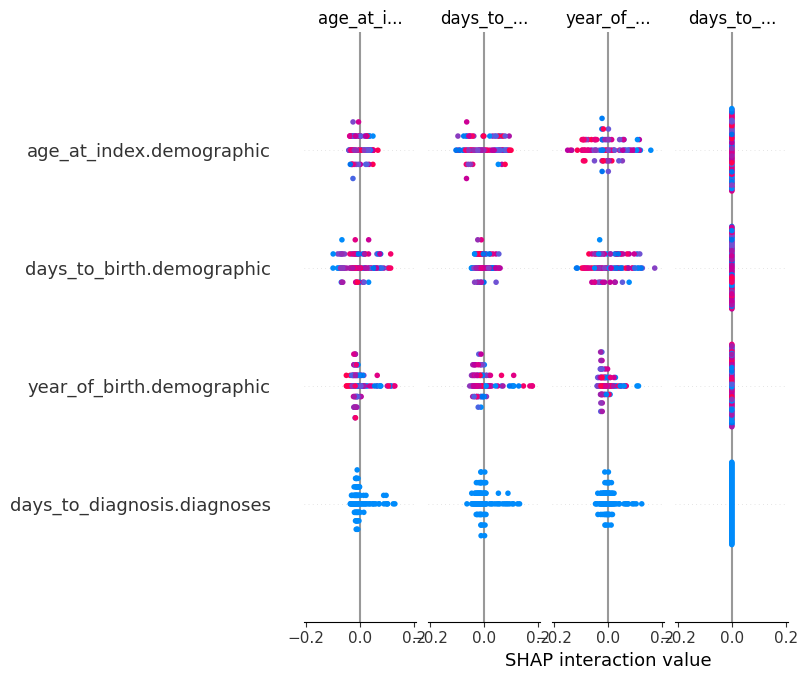

In [ ]:
from sklearn.model_selection import cross_val_score
import shap

# Cross validation
cv_scores = cross_val_score(rf, X_selected, y, cv=5)
print("CV mean accuracy:", np.mean(cv_scores))

# SHAP interpretability
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_selected[:100])  # subset for speed
shap.summary_plot(shap_values, features=X_scaled.iloc[:100, :], feature_names=X_scaled.columns)

In [ ]:
import os

# Path ke folder utama dataset
base_dir = "/content/drive/MyDrive/TCGA_KICH"

# Menyimpan semua path file .nii atau .nii.gz
nii_files = []

# Menelusuri seluruh subfolder
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith(".nii") or file.endswith(".nii.gz"):
            nii_files.append(os.path.join(root, file))

# Jumlah total file
print(f"Total file NIfTI ditemukan: {len(nii_files)}")

# Contoh beberapa file pertama
print("\nContoh file:")
for f in nii_files[:10]:
    print(f)

Total file NIfTI ditemukan: 0

Contoh file:


In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
nii_path = "/content/drive/MyDrive/TCGA-KICH/TCGA-KM-8438/10-31-1991-NA-ABD-18456/1 ABDOMEN SCOUT segmentation.nii"

In [ ]:
# Membaca file NIfTI
img = nib.load(nii_path)

# Ambil data array voxel
data = img.get_fdata()

# Cek informasi dasar
print("=== INFORMASI DASAR ===")
print("Shape (dimensi):", data.shape)
print("Tipe data voxel:", data.dtype)
print("Affine matrix:\n", img.affine)

# Statistik voxel
print("\n=== STATISTIK DATA ===")
print("Nilai minimum voxel:", np.min(data))
print("Nilai maksimum voxel:", np.max(data))
print("Rata-rata voxel:", np.mean(data))

=== INFORMASI DASAR ===
Shape (dimensi): (512, 512, 47)
Tipe data voxel: float64
Affine matrix:
 [[  -0.68359399    0.            0.          150.        ]
 [   0.           -0.68359399    0.          175.        ]
 [   0.            0.           10.         -440.        ]
 [   0.            0.            0.            1.        ]]

=== STATISTIK DATA ===
Nilai minimum voxel: 0.0
Nilai maksimum voxel: 70.0
Rata-rata voxel: 4.181686644858503


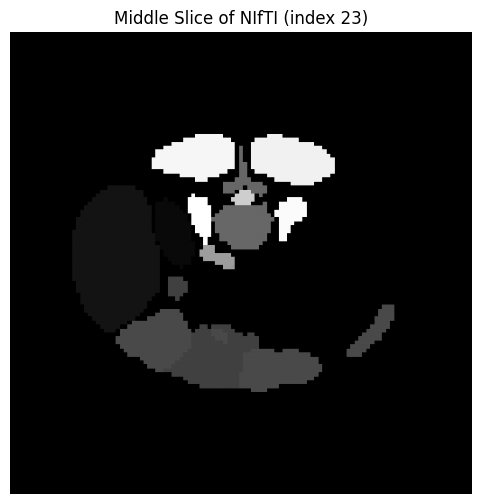

In [ ]:
# Ambil indeks tengah dari sumbu z
mid_slice = data.shape[2] // 2

plt.figure(figsize=(6,6))
plt.imshow(data[:, :, mid_slice].T, cmap="gray", origin="lower")
plt.title(f"Middle Slice of NIfTI (index {mid_slice})")
plt.axis("off")
plt.show()

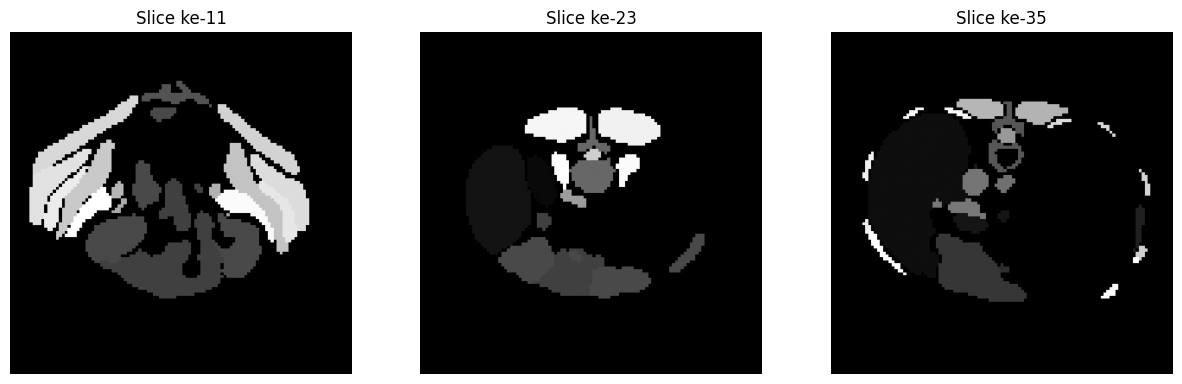

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
indices = [data.shape[2]//4, data.shape[2]//2, 3*data.shape[2]//4]

for i, idx in enumerate(indices):
    axs[i].imshow(data[:, :, idx].T, cmap='gray', origin='lower')
    axs[i].set_title(f'Slice ke-{idx}')
    axs[i].axis('off')

plt.show()

In [ ]:
!pip install medpy scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 10.2 MB/s eta 0:00:00
  Created wheel for medpy: filename=MedPy-0.5.2-py3-none-any.whl size=224710 sha256=a64d2770bd03962e0c3fcbb3925d3a88f5a8464b626fde074a92396a01166b94
  Stored in directory: /root/.cache/pip/wheels/89/5a/f8/b3def53b9c2133d2f8698ea2173bb5df63bd8e761ce8e9aec9
Successfully built medpy


In [ ]:
# Install PyRadiomics di Google Colab
!pip install -q SimpleITK==2.3.0 nibabel
!git clone https://github.com/AIM-Harvard/pyradiomics.git
%cd pyradiomics
!pip install .
%cd /content

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for SimpleITK (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for SimpleITK
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (SimpleITK)
Cloning into 'pyradiomics'...
remote: Enumerating objects: 7320, done.
remote: Counting objects: 100% (1753/1753), done.
remote: Compressing objects: 100% (335/335), done.
remote: Total 7320 (delta 1527), reused 1418 (delta 1418), pack-reused 5567 (from 3)
Receiving objects: 100% (7320/7320), 57.89 MiB | 10.91 MiB/s, done.
Resolving deltas: 100% (4914/4914), done.
/content/pyradiomics
P

In [ ]:
import radiomics
from radiomics import featureextractor

print("✅ PyRadiomics berhasil di-load!")
print("Versi:", radiomics.__version__)

✅ PyRadiomics berhasil di-load!
Versi: 3.1.1.dev111+g8ed579383


In [ ]:
import os
import nibabel as nib
from radiomics import featureextractor
import pandas as pd

In [ ]:
# Update these paths with the actual locations of your image and mask files
# Make sure image_path points to the .nii or .nii.gz image file, not a directory
image_path = "/content/drive/MyDrive/TCGA-KICH/TCGA-KM-8438/10-31-1991-NA-ABD-18456/1.000000-ABDOMEN SCOUT-70134"
# image_path = "/content/drive/MyDrive/TCGA-KICH/TCGA-KM-8438/10-31-1991-NA-ABD-18456/1 ABDOMEN SCOUT.nii" # Update this path
mask_path = "/content/drive/MyDrive/TCGA-KICH/TCGA-KM-8438/10-31-1991-NA-ABD-18456/1 ABDOMEN SCOUT segmentation.nii"

In [ ]:
# Konfigurasi PyRadiomics
params = {
    'binWidth': 25,
    'resampledPixelSpacing': None,
    'interpolator': 'sitkBSpline',
    'normalize': True,
    'normalizeScale': 100,
    # Specify the label value in the mask that corresponds to the region of interest
    'label': 70
}

extractor = featureextractor.RadiomicsFeatureExtractor(**params)
print("Fitur yang akan diekstraksi:")
# print(extractor.enabledFeatures) # This might print a lot, better to print categories
print("Enabled feature classes:", list(extractor.enabledFeatures.keys()))

INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}
INFO:radiomics.featureextractor:Applying custom setting overrides: {'binWidth': 25, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'normalize': True, 'normalizeScale': 100, 'label': 70}


Fitur yang akan diekstraksi:
Enabled feature classes: ['firstorder', 'glcm', 'gldm', 'glrlm', 'glszm', 'ngtdm', 'shape']


In [ ]:
import SimpleITK as sitk

# Ekstraksi fitur radiomics
# Load image and mask using SimpleITK first
try:
    image = sitk.ReadImage(image_path)
    mask = sitk.ReadImage(mask_path)

    # Ensure mask has the same origin, spacing, and direction as the image
    # This is a common requirement for radiomics feature extraction
    mask.SetOrigin(image.GetOrigin())
    mask.SetSpacing(image.GetSpacing())
    mask.SetDirection(image.GetDirection())

    result = extractor.execute(image, mask)

    # Konversi ke DataFrame untuk analysis
    features_df = pd.DataFrame.from_dict(result, orient='index', columns=['Value'])
    features_df = features_df.reset_index().rename(columns={'index': 'Feature'})

    # Tampilkan 10 fitur pertama
    print(features_df.head(10))

except Exception as e:
    print(f"An error occurred during feature extraction: {e}")

An error occurred during feature extraction: Exception thrown in SimpleITK ImageFileReader_Execute: /tmp/SimpleITK/Code/IO/src/sitkImageReaderBase.cxx:99:
sitk::ERROR: Unable to determine ImageIO reader for "/content/drive/MyDrive/TCGA-KICH/TCGA-KM-8438/10-31-1991-NA-ABD-18456/1.000000-ABDOMEN SCOUT-70134"


In [ ]:
output_path = "/content/drive/MyDrive/TCGA-KICH/features_TCGA-KM-8438.csv"

# Check if features_df exists and is not empty before saving
if 'features_df' in locals() and not features_df.empty:
    features_df.to_csv(output_path, index=False)
    print("✅ Fitur berhasil disimpan ke:", output_path)
else:
    print("⚠️ Fitur tidak dapat disimpan. 'features_df' tidak ditemukan atau kosong. Pastikan langkah ekstraksi fitur berjalan sukses.")

⚠️ Fitur tidak dapat disimpan. 'features_df' tidak ditemukan atau kosong. Pastikan langkah ekstraksi fitur berjalan sukses.


In [ ]:
import SimpleITK as sitk
import os

# Folder DICOM (bukan file tunggal)
dicom_dir = "/content/drive/MyDrive/TCGA-KICH/TCGA-KM-8438/10-31-1991-NA-ABD-18456/1.000000-ABDOMEN SCOUT-70134"

# File mask .nii
mask_path = "/content/drive/MyDrive/TCGA-KICH/TCGA-KM-8438/10-31-1991-NA-ABD-18456/1 ABDOMEN SCOUT segmentation.nii"

In [ ]:
import os

path = "/content/drive/MyDrive/TCGA-KICH/TCGA-KM-8438/10-31-1991-NA-ABD-18456"
print("Isi folder:", os.listdir(path))

Isi folder: ['1 ABDOMEN SCOUT segmentation.nii', '4.000000-POST ABDOMEN-96072', '2.000000-PRE LIVER-47636', '1.000000-ABDOMEN SCOUT-70134', '3.000000-Recon 2 PRE LIVER-66472']


In [ ]:
import SimpleITK as sitk
import pandas as pd
from radiomics import featureextractor

# Path ke file NIfTI
image_path = "/content/drive/MyDrive/TCGA-KICH/TCGA-KM-8438/10-31-1991-NA-ABD-18456/1 ABDOMEN SCOUT segmentation.nii"

# Load citra NIfTI
image = sitk.ReadImage(image_path)

# Jika belum punya mask, buat mask otomatis (semua voxel > 0 dianggap ROI)
mask = sitk.BinaryThreshold(image, lowerThreshold=1)

# Buat extractor (dengan konfigurasi default)
extractor = featureextractor.RadiomicsFeatureExtractor()

# Jalankan ekstraksi fitur
result = extractor.execute(image, mask)

# Konversi hasil ke DataFrame
features_df = pd.DataFrame(list(result.items()), columns=['Feature', 'Value'])
print(features_df.head(10))

INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Computing shape
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firsto

                                       Feature  \
0             diagnostics_Versions_PyRadiomics   
1                   diagnostics_Versions_Numpy   
2               diagnostics_Versions_SimpleITK   
3               diagnostics_Versions_PyWavelet   
4                  diagnostics_Versions_Python   
5           diagnostics_Configuration_Settings   
6  diagnostics_Configuration_EnabledImageTypes   
7              diagnostics_Image-original_Hash   
8    diagnostics_Image-original_Dimensionality   
9           diagnostics_Image-original_Spacing   

                                               Value  
0                            3.1.1.dev111+g8ed579383  
1                                              2.0.2  
2                                              2.5.2  
3                                              1.8.0  
4                                            3.12.12  
5  {'minimumROIDimensions': 2, 'minimumROISize': ...  
6                                   {'Original': {}}  
7        

In [ ]:
# --- Tahap 4.1: Membersihkan data radiomics ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ambil hanya fitur numerik (hilangkan baris 'diagnostics' dari PyRadiomics)
features_df_clean = features_df[~features_df['Feature'].str.contains('diagnostics')]
features_df_clean.reset_index(drop=True, inplace=True)

# Ubah ke format wide: kolom = nama fitur, baris = 1 sample
X = features_df_clean['Value'].astype(float).values.reshape(1, -1)
feature_names = features_df_clean['Feature'].tolist()
X = pd.DataFrame(X, columns=feature_names)

# Jika punya label (misalnya jenis kanker ginjal)
# Contoh dummy label: 1 = clear cell, 0 = chromophobe
y = pd.Series([1])  # Ganti sesuai label kamu

In [ ]:
import os
import SimpleITK as sitk
from radiomics import featureextractor

extractor = featureextractor.RadiomicsFeatureExtractor()

# Path ke folder pasien
base_path = "/content/drive/MyDrive/TCGA-KICH/"

data_rows = []
labels = []  # isi manual sesuai klasifikasi kamu

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith(".nii"):
            image_path = os.path.join(root, file)
            image = sitk.ReadImage(image_path)
            mask = sitk.BinaryThreshold(image, lowerThreshold=1)

            result = extractor.execute(image, mask)
            clean_features = {k: v for k, v in result.items() if not k.startswith("diagnostics")}
            data_rows.append(clean_features)
            # contoh label dummy
            labels.append(1 if "KM-8438" in image_path else 0)

# Hasil ekstraksi seluruh pasien
X = pd.DataFrame(data_rows)
y = pd.Series(labels)

INFO:radiomics.featureextractor:No valid config parameter, using defaults: {'minimumROIDimensions': 2, 'minimumROISize': None, 'normalize': False, 'normalizeScale': 1, 'removeOutliers': None, 'resampledPixelSpacing': None, 'interpolator': 'sitkBSpline', 'preCrop': False, 'padDistance': 5, 'distances': [1], 'force2D': False, 'force2Ddimension': 0, 'resegmentRange': None, 'label': 1, 'additionalInfo': True}
INFO:radiomics.featureextractor:Enabled image types: {'Original': {}}
INFO:radiomics.featureextractor:Enabled features: {'firstorder': [], 'glcm': [], 'gldm': [], 'glrlm': [], 'glszm': [], 'ngtdm': [], 'shape': []}
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Computing shape
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firsto

In [ ]:
# Split data train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standarisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Pilih 20 fitur terbaik berdasarkan ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=20)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Simpan nama fitur yang dipilih
selected_features = X.columns[selector.get_support()]
print("Fitur terpilih:\n", selected_features.tolist())

Fitur terpilih:
 ['original_glszm_GrayLevelNonUniformityNormalized', 'original_glszm_GrayLevelVariance', 'original_glszm_HighGrayLevelZoneEmphasis', 'original_glszm_LargeAreaEmphasis', 'original_glszm_LargeAreaHighGrayLevelEmphasis', 'original_glszm_LargeAreaLowGrayLevelEmphasis', 'original_glszm_LowGrayLevelZoneEmphasis', 'original_glszm_SizeZoneNonUniformity', 'original_glszm_SizeZoneNonUniformityNormalized', 'original_glszm_SmallAreaEmphasis', 'original_glszm_SmallAreaHighGrayLevelEmphasis', 'original_glszm_SmallAreaLowGrayLevelEmphasis', 'original_glszm_ZoneEntropy', 'original_glszm_ZonePercentage', 'original_glszm_ZoneVariance', 'original_ngtdm_Busyness', 'original_ngtdm_Coarseness', 'original_ngtdm_Complexity', 'original_ngtdm_Contrast', 'original_ngtdm_Strength']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msb = ssbn / float(dfbn)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:108: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


In [ ]:
import numpy as np

print("Distribusi label di y_train:", np.unique(y_train, return_counts=True))
print("Distribusi label di y_test:", np.unique(y_test, return_counts=True))

Distribusi label di y_train: (array([0]), array([1]))
Distribusi label di y_test: (array([1]), array([1]))


In [ ]:
from sklearn.model_selection import train_test_split

# Use the X and y from the clinical data preprocessing
X_train_selected, X_test_selected, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

ValueError: Found input variables with inconsistent numbers of samples: [105, 2]

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1️⃣ Load dataset
# Specify the tab separator for the TSV file and skip bad lines
data = pd.read_csv("/content/drive/MyDrive/TCGA-KICH/TCGA-KICH.clinical.tsv", sep="\t", on_bad_lines='skip')
print("Shape:", data.shape)
display(data.head())

# Print column names to check if they are parsed correctly
print("\nColumn names after loading:\n", data.columns.tolist())

# 2️⃣ Cek missing values
print("\nMissing Values:\n", data.isnull().sum())

# 3️⃣ Hapus kolom dengan missing value terlalu banyak (>50%)
threshold = len(data) * 0.5
data = data.dropna(thresh=threshold, axis=1)

# 4️⃣ Imputasi nilai kosong dengan median untuk numeric dan modus untuk kategori
for col in data.columns:
    if data[col].dtype == 'object':
        # Use .iloc[0] to handle cases where mode might return multiple values
        data[col].fillna(data[col].mode().iloc[0], inplace=True)
    else:
        data[col].fillna(data[col].median(), inplace=True)

# 5️⃣ Encode label target
# Use the correct label column identified previously
label_col = 'ajcc_pathologic_stage.diagnoses'
le = LabelEncoder()
# Ensure the label column exists after dropping columns with too many missing values
if label_col in data.columns:
  data[label_col] = le.fit_transform(data[label_col])
else:
  raise ValueError(f"Label column '{label_col}' not found after dropping columns with missing values.")


# 6️⃣ Pisahkan fitur dan label
X = data.drop(columns=[label_col])
y = data[label_col]

# 7️⃣ Normalisasi (Standard Scaler)
scaler = StandardScaler()
# Ensure that only numeric columns are scaled
X_numeric = X.select_dtypes(include=np.number)
X_scaled = pd.DataFrame(scaler.fit_transform(X_numeric), columns=X_numeric.columns)

# You might want to keep non-numeric columns separately or decide how to handle them
# For now, X_scaled only contains the scaled numeric features.

Shape: (105, 89)


,sample,id,disease_type,case_id,submitter_id,primary_site,cigarettes_per_day.exposures,alcohol_history.exposures,years_smoked.exposures,race.demographic,...,specimen_type.samples,is_ffpe.samples,tissue_type.samples,preservation_method.samples,days_to_collection.samples,initial_weight.samples,intermediate_dimension.samples,pathology_report_uuid.samples,shortest_dimension.samples,longest_dimension.samples
0,TCGA-UW-A72Q-01A,e2ee1ddf-985e-491e-8e0c-39f9731fee7a,Adenomas and Adenocarcinomas,e2ee1ddf-985e-491e-8e0c-39f9731fee7a,TCGA-UW-A72Q,Kidney,NaN,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,366.0,250.0,NaN,6523685F-8E71-4BC6-8402-F3FBD3332F32,NaN,NaN
1,TCGA-NP-A5H6-01A,8ee83284-3cdd-44d9-a3e2-2a567f10b605,Adenomas and Adenocarcinomas,8ee83284-3cdd-44d9-a3e2-2a567f10b605,TCGA-NP-A5H6,Kidney,NaN,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,325.0,90.0,NaN,F5F15B2B-759D-4195-8C33-33C1D6DF8F25,NaN,NaN
2,TCGA-NP-A5H1-01A,c8890a69-cd2f-41d1-9280-769932228690,Adenomas and Adenocarcinomas,c8890a69-cd2f-41d1-9280-769932228690,TCGA-NP-A5H1,Kidney,NaN,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,517.0,70.0,NaN,6B36ACD0-3F89-4240-8A34-9765FA673403,NaN,NaN
3,TCGA-NP-A5H5-01A,b947dcf8-c83a-4bb0-b517-6b5989421c61,Adenomas and Adenocarcinomas,b947dcf8-c83a-4bb0-b517-6b5989421c61,TCGA-NP-A5H5,Kidney,NaN,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,337.0,60.0,NaN,CFC9112B-5398-4692-AD18-4055BC8EF49D,NaN,NaN
4,TCGA-UW-A72K-01A,b9356af2-c448-4809-ae29-e8b80f65fa73,Adenomas and Adenocarcinomas,b9356af2-c448-4809-ae29-e8b80f65fa73,TCGA-UW-A72K,Kidney,1.643836,Not Reported,NaN,white,...,Solid Tissue,False,Tumor,Unknown,709.0,560.0,NaN,1BBCA936-0E8A-4485-A26E-EA998B326F54,NaN,NaN



Column names after loading:
 ['sample', 'id', 'disease_type', 'case_id', 'submitter_id', 'primary_site', 'cigarettes_per_day.exposures', 'alcohol_history.exposures', 'years_smoked.exposures', 'race.demographic', 'gender.demographic', 'ethnicity.demographic', 'vital_status.demographic', 'age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'year_of_death.demographic', 'primary_site.project', 'project_id.project', 'disease_type.project', 'name.project', 'name.program.project', 'tissue_source_site_id.tissue_source_site', 'code.tissue_source_site', 'name.tissue_source_site', 'project.tissue_source_site', 'bcr_id.tissue_source_site', 'pack_years_smoked.exposures', 'days_to_death.demographic', 'entity_submitter_id.annotations', 'notes.annotations', 'submitter_id.annotations', 'classification.annotations', 'entity_id.annotations', 'created_datetime.annotations', 'annotation_id.annotations', 'entity_type.annotations', 'updated_datetime.annotations', 'case_id.an

/tmp/ipython-input-3388954050.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode().iloc[0], inplace=True)
/tmp/ipython-input-3388954050.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

NameError: name 'label' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

# Use the X and y from the clinical data preprocessing
X_train_selected, X_test_selected, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

ValueError: Found input variables with inconsistent numbers of samples: [105, 2]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_selected, y_train)
y_pred_rf = rf.predict(X_test_selected)

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Model SVM
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_selected, y_train)
y_pred_svm = svm.predict(X_test_selected)

print("\n=== SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== Random Forest ===
Accuracy: 0.0
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

ValueError: The number of classes has to be greater than one; got 1 class

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_train_selected, y_train, cv=5)
print("\nCross-validation mean accuracy (RF):", cv_scores.mean())

cv_scores_svm = cross_val_score(svm, X_train_selected, y_train, cv=5)
print("Cross-validation mean accuracy (SVM):", cv_scores_svm.mean())

ValueError: Cannot have number of splits n_splits=5 greater than the number of samples: n_samples=1.

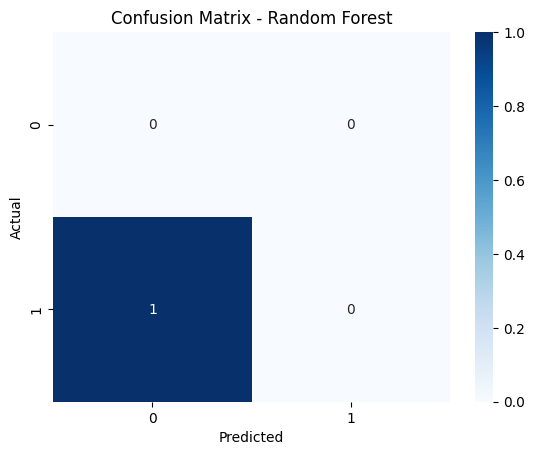

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import joblib

# Simpan data fitur
X.to_csv("radiomics_features.csv", index=False)

# Simpan model
joblib.dump(rf, "random_forest_radiomics.pkl")
print("Model & fitur berhasil disimpan.")

Model & fitur berhasil disimpan.


ANOVA F-Test

In [ ]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.impute import SimpleImputer
import pandas as pd

# ==========================
# 1️⃣ Pastikan X_var sudah ada (hasil fitur setelah preprocessing)
# ==========================
# Jika kamu masih punya X (data fitur mentah dari metadata)
# dan ingin memfilter kolom numerik saja:
X_num = X.select_dtypes(include=['number']).copy()

# Imputer untuk mengisi nilai NaN (misalnya pakai mean)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_num)
X_imputed = pd.DataFrame(X_imputed, columns=X_num.columns)

# ==========================
# 2️⃣ Hilangkan fitur dengan variasi sangat kecil
# ==========================
vt = VarianceThreshold(threshold=0.0)
X_var = vt.fit_transform(X_imputed)
selected_cols_vt = X_num.columns[vt.get_support()]

print(f"Jumlah fitur setelah Variance Threshold: {len(selected_cols_vt)}")

# ==========================
# 3️⃣ Pilih 50 fitur terbaik (ANOVA F-test)
# ==========================
k = 50
selector_f = SelectKBest(score_func=f_classif, k=min(k, X_var.shape[1]))  # antisipasi jika fitur < 50
X_f = selector_f.fit_transform(X_var, y)

# Dapatkan nama fitur terpilih
selected_features_f = selected_cols_vt[selector_f.get_support()]

print("\n✅ Top 10 fitur (ANOVA F-test):")
print(selected_features_f[:10].tolist())
print(f"\nTotal fitur terpilih: {len(selected_features_f)}")

# Jika ingin simpan ke CSV:
selected_features_df = pd.DataFrame({
    "selected_features": selected_features_f
})
selected_features_df.to_csv("/content/drive/MyDrive/TCGA-KICH/selected_features_anova.csv", index=False)
print("📁 Fitur tersimpan di: /content/drive/MyDrive/TCGA-KICH/selected_features_anova.csv")

Jumlah fitur setelah Variance Threshold: 19

✅ Top 10 fitur (ANOVA F-test):
['cigarettes_per_day.exposures', 'years_smoked.exposures', 'age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'year_of_death.demographic', 'pack_years_smoked.exposures', 'days_to_death.demographic', 'days_to_last_follow_up.diagnoses', 'age_at_diagnosis.diagnoses']

Total fitur terpilih: 19
📁 Fitur tersimpan di: /content/drive/MyDrive/TCGA-KICH/selected_features_anova.csv


Mutual Information

In [ ]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif
from sklearn.impute import SimpleImputer
import pandas as pd

# ==========================
# 1️⃣ Preprocessing fitur
# ==========================
# Ambil hanya kolom numerik
X_num = X.select_dtypes(include=['number']).copy()

# Imputer: isi nilai NaN dengan rata-rata kolom
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_num)
X_imputed = pd.DataFrame(X_imputed, columns=X_num.columns)

# ==========================
# 2️⃣ Hilangkan fitur dengan variasi sangat kecil
# ==========================
vt = VarianceThreshold(threshold=0.0)
X_var = vt.fit_transform(X_imputed)
selected_cols_vt = X_num.columns[vt.get_support()]

print(f"Jumlah fitur setelah Variance Threshold: {len(selected_cols_vt)}")

# ==========================
# 3️⃣ Pilih 50 fitur terbaik (ANOVA F-test)
# ==========================
k = 50
selector_f = SelectKBest(score_func=f_classif, k=min(k, X_var.shape[1]))
X_f = selector_f.fit_transform(X_var, y)
selected_features_f = selected_cols_vt[selector_f.get_support()]

print("\n✅ Top 10 fitur (ANOVA F-test):")
print(selected_features_f[:10].tolist())

# ==========================
# 4️⃣ Pilih 50 fitur terbaik (Mutual Information)
# ==========================
selector_mi = SelectKBest(score_func=mutual_info_classif, k=min(k, X_var.shape[1]))
X_mi = selector_mi.fit_transform(X_var, y)
selected_features_mi = selected_cols_vt[selector_mi.get_support()]

print("\n✅ Top 10 fitur (Mutual Information):")
print(selected_features_mi[:10].tolist())

# ==========================
# 5️⃣ Simpan hasil seleksi fitur
# ==========================
selected_features_df = pd.DataFrame({
    "ANOVA_Ftest": selected_features_f,
    "Mutual_Info": selected_features_mi
})
output_path = "/content/drive/MyDrive/TCGA-KICH/selected_features_all.csv"
selected_features_df.to_csv(output_path, index=False)

print(f"\n📁 Fitur tersimpan di: {output_path}")

Jumlah fitur setelah Variance Threshold: 19

✅ Top 10 fitur (ANOVA F-test):
['cigarettes_per_day.exposures', 'years_smoked.exposures', 'age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'year_of_death.demographic', 'pack_years_smoked.exposures', 'days_to_death.demographic', 'days_to_last_follow_up.diagnoses', 'age_at_diagnosis.diagnoses']

✅ Top 10 fitur (Mutual Information):
['cigarettes_per_day.exposures', 'years_smoked.exposures', 'age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'year_of_death.demographic', 'pack_years_smoked.exposures', 'days_to_death.demographic', 'days_to_last_follow_up.diagnoses', 'age_at_diagnosis.diagnoses']

📁 Fitur tersimpan di: /content/drive/MyDrive/TCGA-KICH/selected_features_all.csv


Recursive Feature Elimination (RFE) dengan SVC

In [ ]:
# =============================================
# FEATURE SELECTION FINAL VERSION (KICH Dataset)
# =============================================

import pandas as pd
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ==========================
# 1️⃣ Preprocessing fitur
# ==========================
# Ambil hanya kolom numerik
X_num = X.select_dtypes(include=['number']).copy()

# Isi nilai NaN dengan rata-rata kolom
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_num)
X_imputed = pd.DataFrame(X_imputed, columns=X_num.columns)

# ==========================
# 2️⃣ Hilangkan fitur dengan variasi sangat kecil
# ==========================
vt = VarianceThreshold(threshold=0.0)
X_var = vt.fit_transform(X_imputed)
selected_cols_vt = X_num.columns[vt.get_support()]

print(f"Jumlah fitur setelah Variance Threshold: {len(selected_cols_vt)}")

# ==========================
# 3️⃣ Pilih 50 fitur terbaik (ANOVA F-test)
# ==========================
k = 50
selector_f = SelectKBest(score_func=f_classif, k=min(k, X_var.shape[1]))
X_f = selector_f.fit_transform(X_var, y)
selected_features_f = selected_cols_vt[selector_f.get_support()]
print("\n✅ Top 10 fitur (ANOVA F-test):")
print(selected_features_f[:10].tolist())

# ==========================
# 4️⃣ Pilih 50 fitur terbaik (Mutual Information)
# ==========================
selector_mi = SelectKBest(score_func=mutual_info_classif, k=min(k, X_var.shape[1]))
X_mi = selector_mi.fit_transform(X_var, y)
selected_features_mi = selected_cols_vt[selector_mi.get_support()]
print("\n✅ Top 10 fitur (Mutual Information):")
print(selected_features_mi[:10].tolist())

# ==========================
# 5️⃣ Pilih 50 fitur terbaik (RFE dengan SVC)
# ==========================
svc = SVC(kernel="linear")
# rfe = RFE(estimator=svc, n_features_to_select=min(k, X_var.shape[1]), step=0.1)
rfe = RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=50, step=0.3)
X_rfe = rfe.fit_transform(X_var, y)

selected_features_rfe = selected_cols_vt[rfe.get_support()]
print("\n✅ Top 10 fitur (RFE - SVC):")
print(selected_features_rfe[:10].tolist())

# ==========================
# 6️⃣ Simpan semua hasil
# ==========================
selected_features_df = pd.DataFrame({
    "ANOVA_Ftest": pd.Series(selected_features_f),
    "Mutual_Info": pd.Series(selected_features_mi),
    "RFE_SVC": pd.Series(selected_features_rfe)
})

output_path = "/content/drive/MyDrive/TCGA-KICH/selected_features_combined.csv"
selected_features_df.to_csv(output_path, index=False)
print(f"\n📁 Semua hasil seleksi fitur tersimpan di: {output_path}")

In [ ]:
# =============================================
# FEATURE SELECTION FINAL VERSION (KICH Dataset)
# =============================================

import pandas as pd
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

# ==========================
# 1️⃣ Preprocessing fitur
# ==========================
# Ambil hanya kolom numerik
X_num = X.select_dtypes(include=['number']).copy()

# Isi nilai NaN dengan rata-rata kolom
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_num)
X_imputed = pd.DataFrame(X_imputed, columns=X_num.columns)

# ==========================
# 2️⃣ Hilangkan fitur dengan variasi sangat kecil
# ==========================
vt = VarianceThreshold(threshold=0.0)
X_var = vt.fit_transform(X_imputed)
selected_cols_vt = X_num.columns[vt.get_support()]

print(f"Jumlah fitur setelah Variance Threshold: {len(selected_cols_vt)}")

# ==========================
# 3️⃣ Pilih 50 fitur terbaik (ANOVA F-test)
# ==========================
k = 50
selector_f = SelectKBest(score_func=f_classif, k=min(k, X_var.shape[1]))
X_f = selector_f.fit_transform(X_var, y)
selected_features_f = selected_cols_vt[selector_f.get_support()]
print("\n✅ Top 10 fitur (ANOVA F-test):")
print(selected_features_f[:10].tolist())

# ==========================
# 4️⃣ Pilih 50 fitur terbaik (Mutual Information)
# ==========================
selector_mi = SelectKBest(score_func=mutual_info_classif, k=min(k, X_var.shape[1]))
X_mi = selector_mi.fit_transform(X_var, y)
selected_features_mi = selected_cols_vt[selector_mi.get_support()]
print("\n✅ Top 10 fitur (Mutual Information):")
print(selected_features_mi[:10].tolist())

# ==========================
# 5️⃣ Pilih 50 fitur terbaik (RFE dengan SVC)
# ==========================
svc = SVC(kernel="linear")
rfe = RFE(estimator=svc, n_features_to_select=min(k, X_var.shape[1]), step=0.1)
X_rfe = rfe.fit_transform(X_var, y)

selected_features_rfe = selected_cols_vt[rfe.get_support()]
print("\n✅ Top 10 fitur (RFE - SVC):")
print(selected_features_rfe[:10].tolist())

# ==========================
# 6️⃣ Simpan semua hasil
# ==========================
selected_features_df = pd.DataFrame({
    "ANOVA_Ftest": pd.Series(selected_features_f),
    "Mutual_Info": pd.Series(selected_features_mi),
    "RFE_SVC": pd.Series(selected_features_rfe)
})

output_path = "/content/drive/MyDrive/TCGA-KICH/selected_features_combined.csv"
selected_features_df.to_csv(output_path, index=False)
print(f"\n📁 Semua hasil seleksi fitur tersimpan di: {output_path}")

In [ ]:
# Simpan hasil setiap metode dengan jumlah fitur berbeda
feature_counts = [10, 20, 30, 40, 50]

for n in feature_counts:
    top_n = selected_features_rfe[:n]  # pakai hasil RFE (bisa diganti F-test atau MI)
    df_n = data[top_n + [label_col]]
    output_path = f"analysisResults/RFE_SVC_{n}.csv"
    df_n.to_csv(output_path, index=False)
    print(f"✅ Disimpan: {output_path}")

NameError: name 'selected_features_rfe' is not defined

In [ ]:
if 'race' in data.columns:
    for n in feature_counts:
        features = selected_features_rfe[:n]
        df_asian = data[data['race'] == 'asian'][features + ['stage']]
        df_black = data[data['race'] == 'black or african american'][features + ['stage']]

        df_asian.rename(columns={'stage': 'label'}, inplace=True)
        df_black.rename(columns={'stage': 'label'}, inplace=True)

        df_asian.to_csv(f"analysisResults/asian_{n}.csv", index_label='sample')
        df_black.to_csv(f"analysisResults/black or african american_{n}.csv", index_label='sample')
        print(f"✅ Subset ras disimpan: asian_{n}.csv & black or african american_{n}.csv")

NameError: name 'data' is not defined

In [ ]:
# ============================================
# Neural Network Experiment Framework (Improved)
# Tujuan: Menguji berbagai konfigurasi model, dataset, dan parameter training
# Lalu menyimpan hasil performanya (accuracy, AUC, F1-score, dsb) ke file CSV.
# ============================================

import os
import time
import random
import logging
import numpy as np
import pandas as pd
from datetime import datetime

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, RMSprop, Nadam
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import AUC

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score, precision_score, accuracy_score

# ============================================
# 1️⃣ Reproducibility
# ============================================
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# ============================================
# 2️⃣ Setup Directory & Logging
# ============================================
results_dir = 'nn_experiment_results'
os.makedirs(results_dir, exist_ok=True)

logging.basicConfig(
    filename=f'{results_dir}/experiment_log.txt',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# ============================================
# 3️⃣ Global Parameters
# ============================================
datasetList = [10, 20, 30, 40, 50]

splitting_sizes = {
    '701010': {'val_size': 0.3, 'test_size': 0.5},
    '801010': {'val_size': 0.2, 'test_size': 0.5},
    '900505': {'val_size': 0.1, 'test_size': 0.5}
}

early_stopping_patience_values = [20, 40, 60]

optimizers = {
    'adam': lambda: Adam(learning_rate=0.001),
    'rmsprop': lambda: RMSprop(learning_rate=0.001, rho=0.9),
    'nadam': lambda: Nadam(learning_rate=0.001)
}

layer_configs = [
    # 1 layer
    (1, 8, 'relu', 0.2),
    (1, 16, 'relu', 0.3),
    (1, 32, 'relu', 0.4),
    # 2 layer
    (2, 16, 'relu', 0.3, 8, 'relu', 0.2),
    (2, 32, 'relu', 0.4, 16, 'relu', 0.3),
]

results_columns = [
    'dataset', 'validation_size', 'test_size', 'num_layers',
    'layer1_neurons', 'layer1_activation', 'layer1_dropout',
    'layer2_neurons', 'layer2_activation', 'layer2_dropout',
    'output_activation', 'optimizer', 'early_stopping_patience',
    'accuracy', 'val_accuracy', 'loss', 'val_loss', 'test_acc', 'test_loss',
    'val_auc', 'test_auc', 'test_f1', 'test_recall', 'test_precision',
    'training_time', 'epochs_trained',
    'asian_accuracy', 'asian_f1', 'asian_recall', 'asian_precision', 'asian_auc',
    'black_accuracy', 'black_f1', 'black_recall', 'black_precision', 'black_auc'
]

all_results = []
experiment_counter = 0
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_file = f"{results_dir}/nn_experiments_{timestamp}.csv"

# ============================================
# 4️⃣ Model Builder Function
# ============================================
def build_model(input_shape, num_layers, l1n, l1a, l1d,
                l2n=None, l2a=None, l2d=None, num_classes=2, opt_func=None):
    inputs = Input(shape=(input_shape,))
    x = Dense(l1n, activation=l1a)(inputs)
    x = Dropout(l1d)(x)

    if num_layers == 2:
        x = Dense(l2n, activation=l2a)(x)
        x = Dropout(l2d)(x)

    output_act = 'sigmoid' if num_classes == 2 else 'softmax'
    outputs = Dense(num_classes, activation=output_act)(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=opt_func(),
        loss='binary_crossentropy' if num_classes == 2 else 'categorical_crossentropy',
        metrics=['accuracy', AUC(name='auc')]
    )
    return model

# ============================================
# 5️⃣ Main Experiment Loop
# ============================================
for feature_amount in datasetList:
    try:
        data_path = f'analysisResults/RFE_SVC_{feature_amount}.csv'
        asian_path = f'analysisResults/asian_{feature_amount}.csv'
        black_path = f'analysisResults/black or african american_{feature_amount}.csv'

        if not os.path.exists(data_path):
            print(f"⚠️ Dataset tidak ditemukan: {data_path}")
            continue

        dataset = pd.read_csv(data_path, sep=',', low_memory=False, index_col='sample').fillna(0)
        asian_test = pd.read_csv(asian_path, index_col='sample').fillna(0)
        black_test = pd.read_csv(black_path, index_col='sample').fillna(0)

        for split_name, split_config in splitting_sizes.items():
            val_size = split_config['val_size']
            test_size = split_config['test_size']

            train, temp = train_test_split(
                dataset,
                test_size=val_size,
                random_state=42,
                stratify=dataset['stage']
            )

            val, test = train_test_split(
                temp,
                test_size=test_size,
                random_state=42,
                stratify=temp['stage']
            )

            X_train = train.drop(['stage'], axis=1).to_numpy().astype(np.float32)
            y_train = train['stage'].to_numpy()
            X_val = val.drop(['stage'], axis=1).to_numpy().astype(np.float32)
            y_val = val['stage'].to_numpy()
            X_test = test.drop(['stage'], axis=1).to_numpy().astype(np.float32)
            y_test = test['stage'].to_numpy()

            X_asian = asian_test.drop(columns=['label']).to_numpy().astype(np.float32)
            y_asian = asian_test['label'].to_numpy()
            X_black = black_test.drop(columns=['label']).to_numpy().astype(np.float32)
            y_black = black_test['label'].to_numpy()

            # Feature check
            if X_asian.shape[1] != X_train.shape[1] or X_black.shape[1] != X_train.shape[1]:
                print(f"⚠️ Feature mismatch in dataset {feature_amount}, lewati...")
                continue

            # Scaling
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_val = scaler.transform(X_val)
            X_test = scaler.transform(X_test)
            X_asian = scaler.transform(X_asian)
            X_black = scaler.transform(X_black)

            # Label encoding
            label_encoder = LabelEncoder()
            all_labels = np.concatenate([y_train, y_val, y_test, y_asian, y_black])
            label_encoder.fit(all_labels)

            y_train = label_encoder.transform(y_train)
            y_val = label_encoder.transform(y_val)
            y_test = label_encoder.transform(y_test)
            y_asian = label_encoder.transform(y_asian)
            y_black = label_encoder.transform(y_black)

            num_classes = len(np.unique(y_train))
            y_train_cat = to_categorical(y_train, num_classes)
            y_val_cat = to_categorical(y_val, num_classes)
            y_test_cat = to_categorical(y_test, num_classes)

            # Loop konfigurasi model
            for layer_config in layer_configs:
                if layer_config[0] == 1:
                    num_layers, l1n, l1a, l1d = layer_config
                    l2n, l2a, l2d = None, None, None
                else:
                    num_layers, l1n, l1a, l1d, l2n, l2a, l2d = layer_config

                for opt_name, opt_func in optimizers.items():
                    for patience in early_stopping_patience_values:
                        experiment_counter += 1
                        print(f"\n🚀 Experiment {experiment_counter}: {feature_amount} features | {opt_name} | patience={patience}")

                        model = build_model(
                            X_train.shape[1], num_layers, l1n, l1a, l1d,
                            l2n, l2a, l2d, num_classes, opt_func
                        )

                        callbacks = [
                            EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
                            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10),
                            ModelCheckpoint(f"{results_dir}/best_model_{feature_amount}_{experiment_counter}.h5",
                                            save_best_only=True, verbose=0)
                        ]

                        start_time = time.time()
                        history = model.fit(
                            X_train, y_train_cat,
                            validation_data=(X_val, y_val_cat),
                            epochs=100,
                            batch_size=32,
                            callbacks=callbacks,
                            verbose=0
                        )
                        training_time = time.time() - start_time

                        # Evaluasi
                        test_loss, test_acc, test_auc = model.evaluate(X_test, y_test_cat, verbose=0)
                        val_loss, val_acc, val_auc = model.evaluate(X_val, y_val_cat, verbose=0)

                        y_pred_test = model.predict(X_test, verbose=0)
                        y_pred_asian = model.predict(X_asian, verbose=0)
                        y_pred_black = model.predict(X_black, verbose=0)

                        # AUC Handling (Binary/Multiclass)
                        if num_classes == 2:
                            test_auc_val = roc_auc_score(y_test, y_pred_test[:, 1])
                            asian_auc = roc_auc_score(y_asian, y_pred_asian[:, 1])
                            black_auc = roc_auc_score(y_black, y_pred_black[:, 1])
                        else:
                            test_auc_val = roc_auc_score(y_test_cat, y_pred_test, multi_class='ovr')
                            asian_auc = roc_auc_score(to_categorical(y_asian), y_pred_asian, multi_class='ovr')
                            black_auc = roc_auc_score(to_categorical(y_black), y_pred_black, multi_class='ovr')

                        y_pred_test_classes = np.argmax(y_pred_test, axis=1)
                        y_pred_asian_classes = np.argmax(y_pred_asian, axis=1)
                        y_pred_black_classes = np.argmax(y_pred_black, axis=1)

                        test_f1 = f1_score(y_test, y_pred_test_classes, average='weighted')
                        test_recall = recall_score(y_test, y_pred_test_classes, average='weighted')
                        test_precision = precision_score(y_test, y_pred_test_classes, average='weighted')

                        asian_accuracy = accuracy_score(y_asian, y_pred_asian_classes)
                        black_accuracy = accuracy_score(y_black, y_pred_black_classes)

                        asian_f1 = f1_score(y_asian, y_pred_asian_classes, average='weighted')
                        asian_recall = recall_score(y_asian, y_pred_asian_classes, average='weighted')
                        asian_precision = precision_score(y_asian, y_pred_asian_classes, average='weighted')

                        black_f1 = f1_score(y_black, y_pred_black_classes, average='weighted')
                        black_recall = recall_score(y_black, y_pred_black_classes, average='weighted')
                        black_precision = precision_score(y_black, y_pred_black_classes, average='weighted')

                        result_row = {
                            'dataset': feature_amount,
                            'validation_size': val_size,
                            'test_size': test_size,
                            'num_layers': num_layers,
                            'layer1_neurons': l1n,
                            'layer1_activation': l1a,
                            'layer1_dropout': l1d,
                            'layer2_neurons': l2n,
                            'layer2_activation': l2a,
                            'layer2_dropout': l2d,
                            'output_activation': 'sigmoid' if num_classes == 2 else 'softmax',
                            'optimizer': opt_name,
                            'early_stopping_patience': patience,
                            'accuracy': history.history['accuracy'][-1],
                            'val_accuracy': val_acc,
                            'loss': history.history['loss'][-1],
                            'val_loss': val_loss,
                            'test_acc': test_acc,
                            'test_loss': test_loss,
                            'val_auc': val_auc,
                            'test_auc': test_auc_val,
                            'test_f1': test_f1,
                            'test_recall': test_recall,
                            'test_precision': test_precision,
                            'training_time': training_time,
                            'epochs_trained': len(history.history['loss']),
                            'asian_accuracy': asian_accuracy,
                            'asian_f1': asian_f1,
                            'asian_recall': asian_recall,
                            'asian_precision': asian_precision,
                            'asian_auc': asian_auc,
                            'black_accuracy': black_accuracy,
                            'black_f1': black_f1,
                            'black_recall': black_recall,
                            'black_precision': black_precision,
                            'black_auc': black_auc
                        }

                        all_results.append(result_row)

                        # Simpan tiap eksperimen
                        pd.DataFrame(all_results).to_csv(results_file, index=False)

    except Exception as e:
        logging.error(f"❌ Error processing dataset {feature_amount}: {e}")
        print(f"❌ Error processing dataset {feature_amount}: {e}")
        continue

# ============================================
# 6️⃣ Summary
# ============================================
if all_results:
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(results_file, index=False)

    print(f"\n✅ Semua eksperimen selesai. Hasil tersimpan di: {results_file}")

    # Menampilkan Top 5 model
    print("\n🏆 Top 5 model berdasarkan Validation Accuracy:")
    top_models = results_df.sort_values('val_accuracy', ascending=False).head(5)
    for i, row in top_models.iterrows():
        print(f"{i+1}. Dataset {row['dataset']} | Val Acc: {row['val_accuracy']:.4f} | Test Acc: {row['test_acc']:.4f} | AUC: {row['test_auc']:.4f}")
else:
    print("\n⚠️ Tidak ada eksperimen yang dijalankan karena file dataset tidak ditemukan.")

⚠️ Dataset tidak ditemukan: analysisResults/RFE_SVC_10.csv
⚠️ Dataset tidak ditemukan: analysisResults/RFE_SVC_20.csv
⚠️ Dataset tidak ditemukan: analysisResults/RFE_SVC_30.csv
⚠️ Dataset tidak ditemukan: analysisResults/RFE_SVC_40.csv
⚠️ Dataset tidak ditemukan: analysisResults/RFE_SVC_50.csv

⚠️ Tidak ada eksperimen yang dijalankan karena file dataset tidak ditemukan.
